In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [59]:
df = pd.read_csv("laptop_price.csv",encoding='latin-1')

In [60]:
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   Product           1303 non-null   object 
 3   TypeName          1303 non-null   object 
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   object 
 6   Cpu               1303 non-null   object 
 7   Ram               1303 non-null   object 
 8   Memory            1303 non-null   object 
 9   Gpu               1303 non-null   object 
 10  OpSys             1303 non-null   object 
 11  Weight            1303 non-null   object 
 12  Price_euros       1303 non-null   float64
dtypes: float64(2), int64(1), object(10)
memory usage: 132.5+ KB


In [62]:
df.describe()

,laptop_ID,Inches,Price_euros
count,1303.000000,1303.000000,1303.000000
mean,660.155794,15.017191,1123.686992
std,381.172104,1.426304,699.009043
min,1.000000,10.100000,174.000000
25%,331.500000,14.000000,599.000000
50%,659.000000,15.600000,977.000000
75%,990.500000,15.600000,1487.880000
max,1320.000000,18.400000,6099.000000


In [63]:
df.isnull().sum()

,0
laptop_ID,0
Company,0
Product,0
TypeName,0
Inches,0
ScreenResolution,0
Cpu,0
Ram,0
Memory,0
Gpu,0


In [64]:
df.duplicated().sum()

np.int64(0)

In [65]:
df.columns

Index(['laptop_ID', 'Company', 'Product', 'TypeName', 'Inches',
       'ScreenResolution', 'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight',
       'Price_euros'],
      dtype='object')

In [66]:
df['Ram']=df['Ram'].str.replace('GB','').astype(int)

In [67]:
df['Weight']=df['Weight'].str.replace('kg','').astype(float)

In [68]:
category =  ['Company','TypeName','ScreenResolution','Cpu','Memory','Gpu','OpSys']

In [69]:
df_encoded = pd.get_dummies(df,columns=category, drop_first=True)

In [70]:
df_encoded

,laptop_ID,Product,Inches,Ram,Weight,Price_euros,Company_Apple,Company_Asus,Company_Chuwi,Company_Dell,...,Gpu_Nvidia Quadro M620,Gpu_Nvidia Quadro M620M,OpSys_Chrome OS,OpSys_Linux,OpSys_Mac OS X,OpSys_No OS,OpSys_Windows 10,OpSys_Windows 10 S,OpSys_Windows 7,OpSys_macOS
0,1,MacBook Pro,13.3,8,1.37,1339.69,True,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,2,Macbook Air,13.3,8,1.34,898.94,True,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,3,250 G6,15.6,8,1.86,575.00,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3,4,MacBook Pro,15.4,16,1.83,2537.45,True,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,5,MacBook Pro,13.3,8,1.37,1803.60,True,False,False,False,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,1316,Yoga 500-14ISK,14.0,4,1.80,638.00,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1299,1317,Yoga 900-13ISK,13.3,16,1.30,1499.00,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1300,1318,IdeaPad 100S-14IBR,14.0,2,1.50,229.00,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1301,1319,15-AC110nv (i7-6500U/6GB/1TB/Radeon,15.6,6,2.19,764.00,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False


In [71]:
df_encoded.drop(columns=['laptop_ID','Product'],inplace=True)

In [72]:
df_encoded=df_encoded.astype(int)

In [73]:
df_encoded

,Inches,Ram,Weight,Price_euros,Company_Apple,Company_Asus,Company_Chuwi,Company_Dell,Company_Fujitsu,Company_Google,...,Gpu_Nvidia Quadro M620,Gpu_Nvidia Quadro M620M,OpSys_Chrome OS,OpSys_Linux,OpSys_Mac OS X,OpSys_No OS,OpSys_Windows 10,OpSys_Windows 10 S,OpSys_Windows 7,OpSys_macOS
0,13,8,1,1339,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,13,8,1,898,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,15,8,1,575,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,15,16,1,2537,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,13,8,1,1803,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,14,4,1,638,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1299,13,16,1,1499,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1300,14,2,1,229,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1301,15,6,2,764,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [74]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Columns: 338 entries, Inches to OpSys_macOS
dtypes: int64(338)
memory usage: 3.4 MB


In [75]:
from sklearn.preprocessing import StandardScaler
numerical_features = ['Inches','Ram','Weight']
scaler = StandardScaler()
df_encoded[numerical_features] = scaler.fit_transform(df_encoded[numerical_features])

In [76]:
from sklearn.model_selection import train_test_split
X = df_encoded.drop(columns=['Price_euros'])
y = df_encoded['Price_euros']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [77]:
X_train.shape

(1042, 337)

In [78]:
y_train.shape

(1042,)

In [79]:
# Building an Ann
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [80]:
model = Sequential()

In [81]:
input_dim = X_train.shape[1]

model.add(Dense(units=128, activation='relu', input_shape=(input_dim,)))
model.add(Dropout(0.2))

model.add(Dense(units=128, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(units=64, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(units=32, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(units=1, activation='linear'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [82]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 128)            │        43,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 70,145 (274.00 KB)

 Trainable params: 70,145 (274.00 KB)

 Non-trainable params: 0 (0.00 B)

In [83]:
early = EarlyStopping(monitor='val_loss', verbose=1,patience=5)

In [84]:
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])

In [85]:
history = model.fit(X_train, y_train, epochs=100, validation_split=0.2, callbacks=[early])

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1753633.7500 - mean_absolute_error: 1124.1324 - val_loss: 1749570.7500 - val_mean_absolute_error: 1137.7203
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1704218.3750 - mean_absolute_error: 1102.8350 - val_loss: 1578088.6250 - val_mean_absolute_error: 1063.2642
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1171180.1250 - mean_absolute_error: 834.8924 - val_loss: 454783.8750 - val_mean_absolute_error: 457.4982
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 390721.0000 - mean_absolute_error: 478.4424 - val_loss: 235077.7969 - val_mean_absolute_error: 334.4021
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 251120.6094 - mean_absolute_error: 353.2556 - val_loss: 177266.1250 - val_mean_absolute_error: 290.1520
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 216566.0156 - mean_absolute_error: 321.0994 - val_loss: 166418.4688 - val_mean_absolute_error: 259.7386
Epoch 7/100
2

In [86]:
y_pred = model.predict(X_test)
y_pred

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


array([[1144.5236 ],
       [1094.9099 ],
       [ 593.2651 ],
       [ 774.91486],
       [1044.596  ],
       [1063.7789 ],
       [ 660.259  ],
       [ 276.56842],
       [1442.5465 ],
       [ 458.65323],
       [1882.5344 ],
       [ 653.127  ],
       [1435.9783 ],
       [ 537.34735],
       [1808.4945 ],
       [1028.3407 ],
       [1320.8027 ],
       [ 897.147  ],
       [1012.40765],
       [1795.4716 ],
       [2049.6663 ],
       [ 343.94037],
       [1264.3099 ],
       [ 294.81262],
       [1061.1111 ],
       [1041.523  ],
       [ 932.6142 ],
       [ 702.55817],
       [1293.5558 ],
       [1237.6986 ],
       [ 539.3105 ],
       [1541.1837 ],
       [1518.6595 ],
       [1012.9131 ],
       [1110.5524 ],
       [ 690.5051 ],
       [ 601.14325],
       [ 601.8774 ],
       [1085.1846 ],
       [ 229.77861],
       [1983.171  ],
       [ 520.3859 ],
       [ 551.6182 ],
       [2145.5054 ],
       [ 505.07825],
       [1165.5409 ],
       [1588.5009 ],
       [ 235.

In [87]:
y_pred_train = model.predict(X_train)
y_pred_train

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


array([[512.56915],
       [403.7075 ],
       [693.6694 ],
       ...,
       [496.6098 ],
       [835.22766],
       [467.25186]], dtype=float32)

In [88]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [89]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [90]:
r2

0.8427768349647522

In [91]:
print(mse)
print(mae)
print(r2)

79855.5625
186.090576171875
0.8427768349647522


Text(0.5, 0, 'epoch')

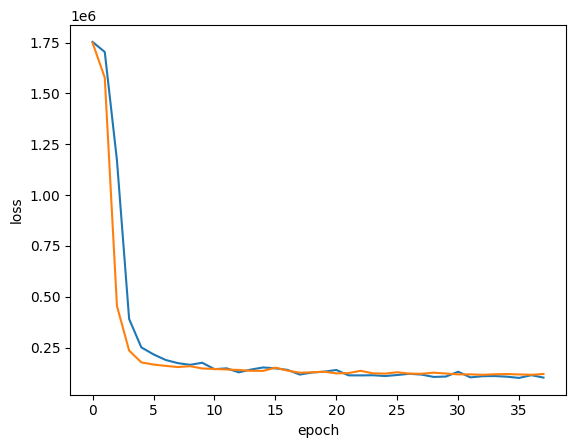

In [92]:
plt.plot(history.history['loss'],label = 'Training Loss')
plt.plot(history.history['val_loss'], label = 'Validation Loss')
plt.ylabel('loss')
plt.xlabel('epoch')